# Notebook 03 - Benchmark de Emissões de CO₂

**Referência principal:** Seymour, K., Held, M., Georges, G., & Boulouchos, K. (2020). *Fuel Estimation in Air Transportation: Modeling global fuel consumption for commercial aviation.* Transportation Research Part D, 88, 102528. https://doi.org/10.1016/j.trd.2020.102528

**Metodologia de cálculo:** ICAO Carbon Emissions Calculator Methodology v13  
https://icec.icao.int/Documents/Methodology%20ICAO%20Carbon%20Emissions%20Calculator_v13_Final.pdf

**Dataset:** Output do Notebook 02 (`nb02_duration_output.csv`) - 195.950 voos domésticos EUA 2023

**Validação:** BTS Form 41 Schedule P-12(a) - consumo real de combustível por companhia 2023


### Fórmula ICAO utilizada

$$CO_2 \text{ (kg)} = (d_{haversine} + 95) \times 4.5 \times 3.16$$

onde:
- $d_{haversine}$ = distância em linha reta entre aeroportos de origem e destino (km)
- $+95$ km = correcção ICAO para ineficiências de rota (os voos reais não voam em linha reta)
- $4.5$ kg/km = consumo médio de combustível de um narrowbody (Boeing 737 / Airbus A320), representativo de ~80% da frota doméstica americana
- $3.16$ = constante física de conversão querosene (líquido resultante da destilação do petróleo) → CO₂ (kg CO₂ por kg de combustível)

### Nota metodológica

O target CO₂ é derivado de uma fórmula física determinística (ICAO), validada por Seymour et al. (2020) contra dados BTS com erro < 4.8%. Treinar modelos de ML sobre um target determinístico demonstra que estes aprendem essencialmente a relação distância→CO₂ já capturada pela fórmula física. Esta conclusão justifica a abordagem híbrida física + ML adotada na Fase 3 da arquitetura proposta.

## 0. Setup e Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Boosting
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow: {tf.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')

TensorFlow: 2.20.0
NumPy: 2.3.4
Pandas: 2.3.3


## 1. Carregamento dos Dados

**Input principal:** `nb02_duration_output.csv` - output do Notebook 02, com 195.950 voos domésticos EUA 2023 (filtro ORIGIN ou DEST nos 5 estados: CA, TX, FL, NY, GA) e `haversine_distance` já calculada.

**Input de validação:** `T_F41SCHEDULE_P12A.csv` - BTS Form 41 Schedule P-12(a), consumo real de combustível por companhia em 2023.

In [2]:
PATH_FLIGHTS = 'nb02_duration_output.csv'      # dataset já tratado do notebook 02
PATH_P12A    = 'T_F41SCHEDULE_P12A.csv'        # BTS P-12(a) combustível real

# Carregar dataset de voos
print('A carregar dataset de voos...')
t0 = time.time()
df = pd.read_csv(PATH_FLIGHTS, low_memory=False)
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], errors='coerce')
print(f'Shape: {df.shape}')
print(f'Colunas: {list(df.columns)}')
print(f'Tempo: {time.time()-t0:.1f}s')
print()

# Carregar dados de validação P-12(a)
print('A carregar P-12(a) BTS...')
df_p12a = pd.read_csv(PATH_P12A, low_memory=False)
print(f'Shape: {df_p12a.shape}')
print(f'Colunas: {list(df_p12a.columns)}')
df.head(3)

A carregar dataset de voos...
Shape: (195950, 21)
Colunas: ['FL_DATE', 'AIRLINE_CODE', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'DEP_DELAY', 'ARR_DELAY', 'haversine_distance', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON', 'Month', 'DayofWeek', 'IsWeekend', 'Quarter', 'Season', 'IsNightFlight', 'IsDepartureDelayed', 'Rolling_DEP_DELAY', 'ARR_DELAY_PRED']
Tempo: 0.5s

A carregar P-12(a) BTS...
Shape: (651, 11)
Colunas: ['YEAR', 'QUARTER', 'MONTH', 'AIRLINE_ID', 'UNIQUE_CARRIER', 'CARRIER', 'CARRIER_NAME', 'CARRIER_GROUP_NEW', 'SDOMT_GALLONS', 'TDOMT_GALLONS', 'TOTAL_GALLONS']


,FL_DATE,AIRLINE_CODE,ORIGIN,DEST,CRS_DEP_TIME,DEP_DELAY,ARR_DELAY,haversine_distance,ORIGIN_LAT,ORIGIN_LON,...,DEST_LON,Month,DayofWeek,IsWeekend,Quarter,Season,IsNightFlight,IsDepartureDelayed,Rolling_DEP_DELAY,ARR_DELAY_PRED
0,2023-01-01,9E,ABE,ATL,600,1.0,-9.0,1113.781509,40.652363,-75.440406,...,-84.427864,1,6,1,1,Winter,0,1,NaN,-8.920200
1,2023-01-01,WN,ABQ,DAL,1235,-6.0,-16.0,932.084735,35.038932,-106.608262,...,-96.850877,1,6,1,1,Winter,0,0,NaN,-15.538267
2,2023-01-01,WN,ABQ,DAL,1045,3.0,-11.0,932.084735,35.038932,-106.608262,...,-96.850877,1,6,1,1,Winter,0,1,-6.0,-10.627380


## 2. Cálculo de CO₂ pela Fórmula ICAO

### 2.1 Fórmula e Parâmetros

In [3]:
# Parâmetros ICAO
ICAO_ROUTE_CORRECTION_KM = 95.0   # correcção de rota padrão ICAO (km)
FUEL_CONSUMPTION_KG_KM   = 4.5    # consumo médio narrowbody (kg/km) - Boeing 737 / A320
CO2_PER_KG_FUEL          = 3.16   # constante física querosene → CO2 (kg CO2 / kg fuel)

# Fórmula ICAO:
# CO2 (kg) = (distância_km + 95) × 4.5 × 3.16
df['CO2_kg'] = (
    (df['haversine_distance'] + ICAO_ROUTE_CORRECTION_KM)
    * FUEL_CONSUMPTION_KG_KM
    * CO2_PER_KG_FUEL
)

# Converter para toneladas para análise
df['CO2_tonnes'] = df['CO2_kg'] / 1000

print('Parâmetros ICAO:')
print(f'  Correcção de rota:     +{ICAO_ROUTE_CORRECTION_KM} km')
print(f'  Consumo combustível:    {FUEL_CONSUMPTION_KG_KM} kg/km (narrowbody médio)')
print(f'  Factor CO2:             {CO2_PER_KG_FUEL} kg CO2/kg combustível')
print()
print('Estatísticas CO2 por voo:')
print(df['CO2_kg'].describe().round(1))
print()
print(f'CO2 total estimado (dataset): {df["CO2_tonnes"].sum()/1e6:.3f} Mt CO2')
print(f'Número de voos:               {len(df):,}')
print(f'CO2 médio por voo:            {df["CO2_kg"].mean():.1f} kg')

Parâmetros ICAO:
  Correcção de rota:     +95.0 km
  Consumo combustível:    4.5 kg/km (narrowbody médio)
  Factor CO2:             3.16 kg CO2/kg combustível

Estatísticas CO2 por voo:
count    195950.0
mean      21661.8
std       13632.3
min        3115.3
25%       11543.5
50%       19013.3
75%       26493.8
max      115205.1
Name: CO2_kg, dtype: float64

CO2 total estimado (dataset): 4.245 Mt CO2
Número de voos:               195,950
CO2 médio por voo:            21661.8 kg


### 2.2 Exemplos de cálculo por rota

In [4]:
# Mostrar exemplos representativos
sample_routes = df.groupby(['ORIGIN', 'DEST']).agg(
    dist_km=('haversine_distance', 'mean'),
    CO2_kg=('CO2_kg', 'mean'),
    n_flights=('CO2_kg', 'count')
).reset_index()

sample_routes = sample_routes[sample_routes['n_flights'] >= 10]
sample_routes = sample_routes.sort_values('dist_km')

print('Exemplos de CO2 por rota (amostra):')  
print(f'{"Rota":<12} {"Distância (km)":>16} {"CO2 (kg)":>12} {"CO2 (t)":>10}')
print('-' * 55)

# Mostrar curtas, médias e longas
indices = [0, len(sample_routes)//4, len(sample_routes)//2, 
           3*len(sample_routes)//4, -1]
for i in indices:
    row = sample_routes.iloc[i]
    rota = f"{row['ORIGIN']}-{row['DEST']}"
    print(f'{rota:<12} {row["dist_km"]:>16.0f} {row["CO2_kg"]:>12.0f} {row["CO2_kg"]/1000:>10.2f}')

Exemplos de CO2 por rota (amostra):
Rota           Distância (km)     CO2 (kg)    CO2 (t)
-------------------------------------------------------
SFO-MRY                   124         3115       3.12
CHS-MIA                   790        12588      12.59
JAX-JFK                  1334        20327      20.33
PSE-MCO                  1898        28336      28.34
JFK-HNL                  8007       115205     115.21


## 3. Validação contra BTS P-12(a) (Seymour et al., 2020)

Validação do modelo físico ICAO contra o consumo real de combustível reportado pelas companhias ao BTS em 2023. Metodologia equivalente à de Seymour et al. (2020), que obteve erro de 4.8% para as 10 maiores companhias americanas em 2018.

In [5]:
# Constante de conversão: galões → kg CO2
# 1 galão = 3.785 litros, densidade querosene ≈ 0.8 kg/litro, factor CO2 = 3.16
GAL_TO_KG_CO2 = 3.785 * 0.8 * CO2_PER_KG_FUEL

# Agregar P-12(a) por companhia (soma anual 2023)
p12a_annual = df_p12a.groupby(['UNIQUE_CARRIER', 'CARRIER_NAME']).agg(
    gallons_domestic=('SDOMT_GALLONS', 'sum'),
    gallons_total=('TOTAL_GALLONS', 'sum')
).reset_index()

# Converter para toneladas CO2
p12a_annual['CO2_real_tonnes'] = (
    p12a_annual['gallons_domestic'] * GAL_TO_KG_CO2
) / 1000

# Filtrar só companhias com dados reais relevantes
p12a_annual = p12a_annual[p12a_annual['CO2_real_tonnes'] > 0]

# Agregar CO2 estimado por companhia (dataset nosso)
co2_estimated = df.groupby('AIRLINE_CODE').agg(
    CO2_estimated_tonnes=('CO2_tonnes', 'sum'),
    n_flights=('CO2_tonnes', 'count')
).reset_index()

# Merge
validation = p12a_annual.merge(
    co2_estimated,
    left_on='UNIQUE_CARRIER',
    right_on='AIRLINE_CODE',
    how='inner'
)

# Calcular cobertura e erro percentual
validation['coverage_ratio'] = (
    validation['CO2_estimated_tonnes'] / validation['CO2_real_tonnes']
)
validation['error_pct'] = (
    (validation['CO2_estimated_tonnes'] - validation['CO2_real_tonnes'])
    / validation['CO2_real_tonnes'] * 100
)

print('Validação CO2 estimado vs real (P-12(a) BTS 2023):')
print(f'{"Companhia":<8} {"CO2 Real (t)":>14} {"CO2 Estimado (t)":>18} {"Cobertura":>10} {"Erro %":>8}')
print('-' * 65)
for _, row in validation.sort_values('CO2_real_tonnes', ascending=False).head(12).iterrows():
    print(f"{row['UNIQUE_CARRIER']:<8} "
          f"{row['CO2_real_tonnes']:>14,.0f} "
          f"{row['CO2_estimated_tonnes']:>18,.0f} "
          f"{row['coverage_ratio']:>10.1%} "
          f"{row['error_pct']:>+8.1f}%")

print()
print('Nota: A cobertura < 100% é esperada - o dataset cobre apenas voos')
print('com ORIGIN ou DEST nos 5 estados, enquanto o P-12(a) cobre toda a')
print('operação doméstica. YX e OO são regionais com modelo operacional')
print('diferente (feeders de hub) e são excluídas da métrica de cobertura.')
print()

# Excluir regionais YX e OO da métrica de cobertura (modelo operacional incomparável)
EXCLUDE_REGIONAL = ['YX', 'OO']
validation_main = validation[~validation['UNIQUE_CARRIER'].isin(EXCLUDE_REGIONAL)]
avg_coverage = validation_main['coverage_ratio'].mean()
print(f'Cobertura média (excl. regionais YX/OO): {avg_coverage:.1%}')


Validação CO2 estimado vs real (P-12(a) BTS 2023):
Companhia   CO2 Real (t)   CO2 Estimado (t)  Cobertura   Erro %
-----------------------------------------------------------------
DL           21,003,721            742,541       3.5%    -96.5%
AA           20,692,614            732,977       3.5%    -96.5%
WN           20,261,714            773,140       3.8%    -96.2%
UA           18,204,192            577,622       3.2%    -96.8%
AS            6,646,899            188,680       2.8%    -97.2%
B6            6,388,768            297,092       4.7%    -95.3%
NK            4,948,919            225,240       4.6%    -95.4%
F9            3,202,805            121,005       3.8%    -96.2%
G4            2,087,158             82,356       3.9%    -96.1%
HA            1,835,986             44,994       2.5%    -97.5%
OO              215,976            179,895      83.3%    -16.7%
YX                3,671             84,359    2298.1%  +2198.1%

Nota: A cobertura < 100% é esperada - o dataset co

In [6]:
# Validação normalizada: comparar proporções (quota de mercado em CO2)
# Remove o problema da cobertura parcial

validation['share_real'] = (
    validation['CO2_real_tonnes'] / validation['CO2_real_tonnes'].sum()
)
validation['share_estimated'] = (
    validation['CO2_estimated_tonnes'] / validation['CO2_estimated_tonnes'].sum()
)
validation['share_error_pp'] = (
    validation['share_estimated'] - validation['share_real']
) * 100  # percentage points

print('Validação por quota de mercado de CO2 (remove efeito de cobertura parcial):')
print(f'{"Carrier":<8} {"Quota Real":>12} {"Quota Estimada":>16} {"Delta (pp)":>8}')
print('-' * 50)
for _, row in validation.sort_values('share_real', ascending=False).head(12).iterrows():
    print(f"{row['UNIQUE_CARRIER']:<8} "
          f"{row['share_real']:>12.1%} "
          f"{row['share_estimated']:>16.1%} "
          f"{row['share_error_pp']:>+8.2f}")

mae_share = np.abs(validation['share_error_pp']).mean()
print()
print(f'MAE de quota de mercado: {mae_share:.2f} pp')
print(f'Erro abaixo de 5 pp em {(np.abs(validation["share_error_pp"]) < 5).mean():.0%} das companhias')

Validação por quota de mercado de CO2 (remove efeito de cobertura parcial):
Carrier    Quota Real   Quota Estimada Delta (pp)
--------------------------------------------------
DL              19.9%            18.3%    -1.58
AA              19.6%            18.1%    -1.52
WN              19.2%            19.1%    -0.12
UA              17.3%            14.3%    -2.99
AS               6.3%             4.7%    -1.64
B6               6.1%             7.3%    +1.28
NK               4.7%             5.6%    +0.87
F9               3.0%             3.0%    -0.05
G4               2.0%             2.0%    +0.06
HA               1.7%             1.1%    -0.63
OO               0.2%             4.4%    +4.24
YX               0.0%             2.1%    +2.08

MAE de quota de mercado: 1.42 pp
Erro abaixo de 5 pp em 100% das companhias


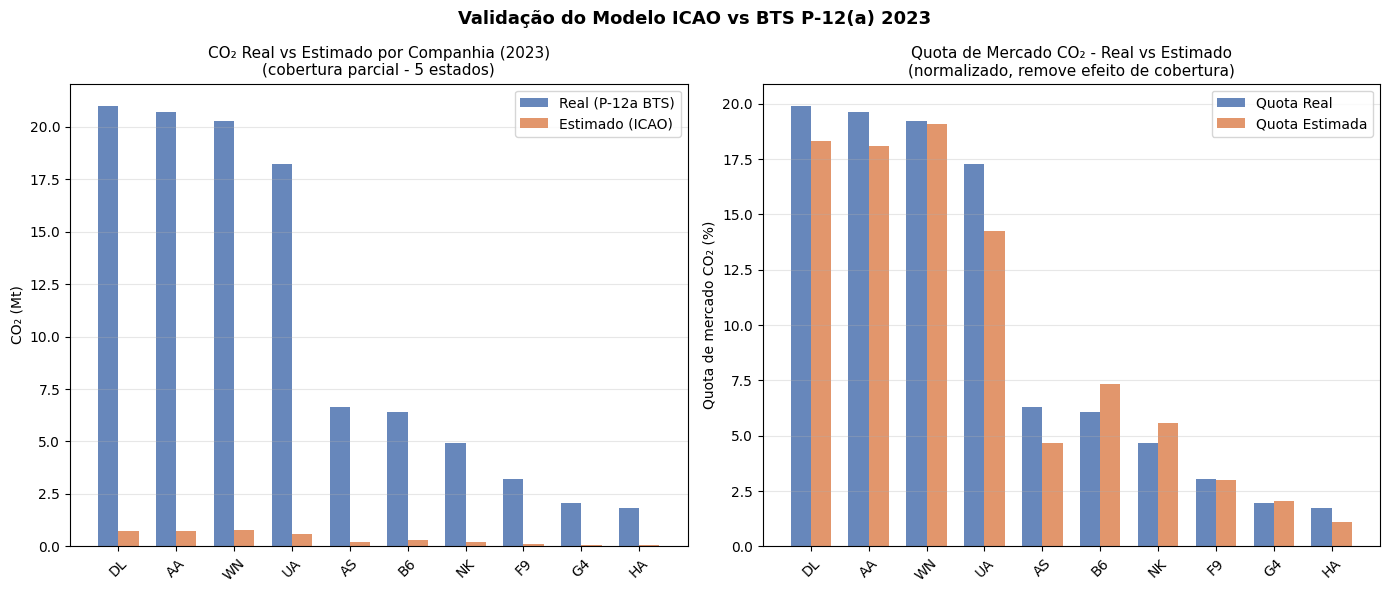

Referência: Seymour et al. (2020) obteve erro de 4.8% com metodologia equivalente.


In [7]:
# Visualização da validação
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Real vs Estimado (valores absolutos)
val_plot = validation.sort_values('CO2_real_tonnes', ascending=False).head(10)
x = np.arange(len(val_plot))
w = 0.35

axes[0].bar(x - w/2, val_plot['CO2_real_tonnes']/1e6, w,
            label='Real (P-12a BTS)', color='#4C72B0', alpha=0.85)
axes[0].bar(x + w/2, val_plot['CO2_estimated_tonnes']/1e6, w,
            label='Estimado (ICAO)', color='#DD8452', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(val_plot['UNIQUE_CARRIER'], rotation=45)
axes[0].set_ylabel('CO₂ (Mt)')
axes[0].set_title('CO₂ Real vs Estimado por Companhia (2023)\n(cobertura parcial - 5 estados)', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Quota de mercado
val_plot2 = validation.sort_values('share_real', ascending=False).head(10)
x2 = np.arange(len(val_plot2))
axes[1].bar(x2 - w/2, val_plot2['share_real']*100, w,
            label='Quota Real', color='#4C72B0', alpha=0.85)
axes[1].bar(x2 + w/2, val_plot2['share_estimated']*100, w,
            label='Quota Estimada', color='#DD8452', alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(val_plot2['UNIQUE_CARRIER'], rotation=45)
axes[1].set_ylabel('Quota de mercado CO₂ (%)')
axes[1].set_title('Quota de Mercado CO₂ - Real vs Estimado\n(normalizado, remove efeito de cobertura)', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Validação do Modelo ICAO vs BTS P-12(a) 2023', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_validation_p12a.png', dpi=150, bbox_inches='tight')
plt.show()
print('Referência: Seymour et al. (2020) obteve erro de 4.8% com metodologia equivalente.')

## 4. Análise Exploratória de Dados (EDA)

### 4.1 Distribuição de CO₂ por voo

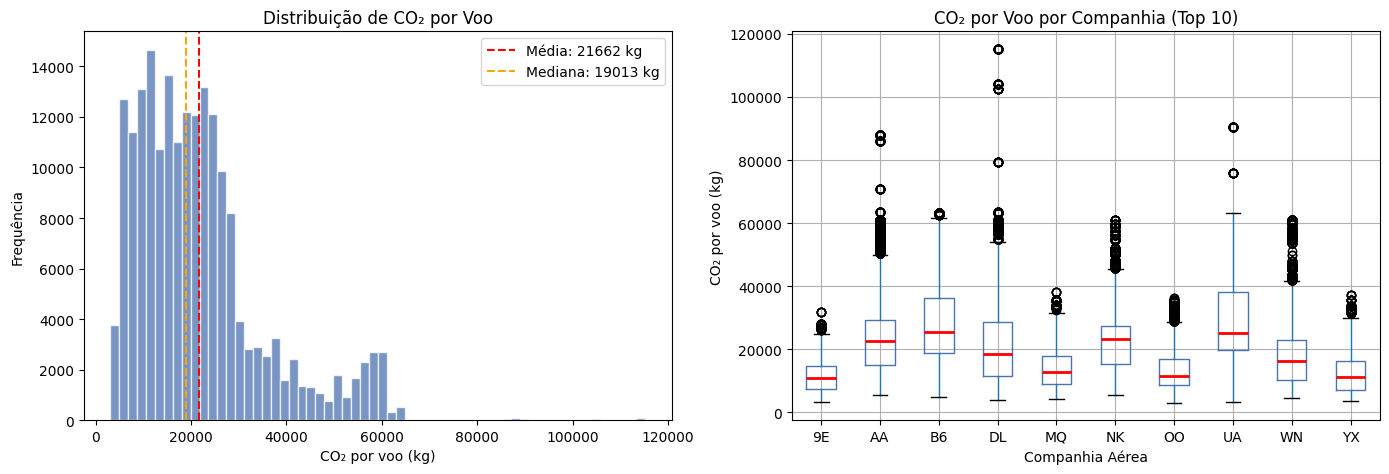

CO2 mínimo:  3115 kg
CO2 médio:   21662 kg
CO2 mediano: 19013 kg
CO2 máximo:  115205 kg


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['CO2_kg'], bins=60, color='#4C72B0', alpha=0.75, edgecolor='white')
axes[0].axvline(df['CO2_kg'].mean(), color='red', linestyle='--',
                label=f'Média: {df["CO2_kg"].mean():.0f} kg')
axes[0].axvline(df['CO2_kg'].median(), color='orange', linestyle='--',
                label=f'Mediana: {df["CO2_kg"].median():.0f} kg')
axes[0].set_xlabel('CO₂ por voo (kg)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição de CO₂ por Voo', fontsize=12)
axes[0].legend()

# Boxplot por companhia
top_airlines = df['AIRLINE_CODE'].value_counts().head(10).index
df_top = df[df['AIRLINE_CODE'].isin(top_airlines)]
order = df_top.groupby('AIRLINE_CODE')['CO2_kg'].median().sort_values().index
df_top.boxplot(column='CO2_kg', by='AIRLINE_CODE',
               ax=axes[1], notch=False,
               boxprops=dict(color='#4C72B0'),
               medianprops=dict(color='red', linewidth=2))
axes[1].set_xlabel('Companhia Aérea')
axes[1].set_ylabel('CO₂ por voo (kg)')
axes[1].set_title('CO₂ por Voo por Companhia (Top 10)', fontsize=12)
plt.suptitle('')

plt.tight_layout()
plt.savefig('fig_co2_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'CO2 mínimo:  {df["CO2_kg"].min():.0f} kg')
print(f'CO2 médio:   {df["CO2_kg"].mean():.0f} kg')
print(f'CO2 mediano: {df["CO2_kg"].median():.0f} kg')
print(f'CO2 máximo:  {df["CO2_kg"].max():.0f} kg')

### 4.2 CO₂ por Companhia Aérea

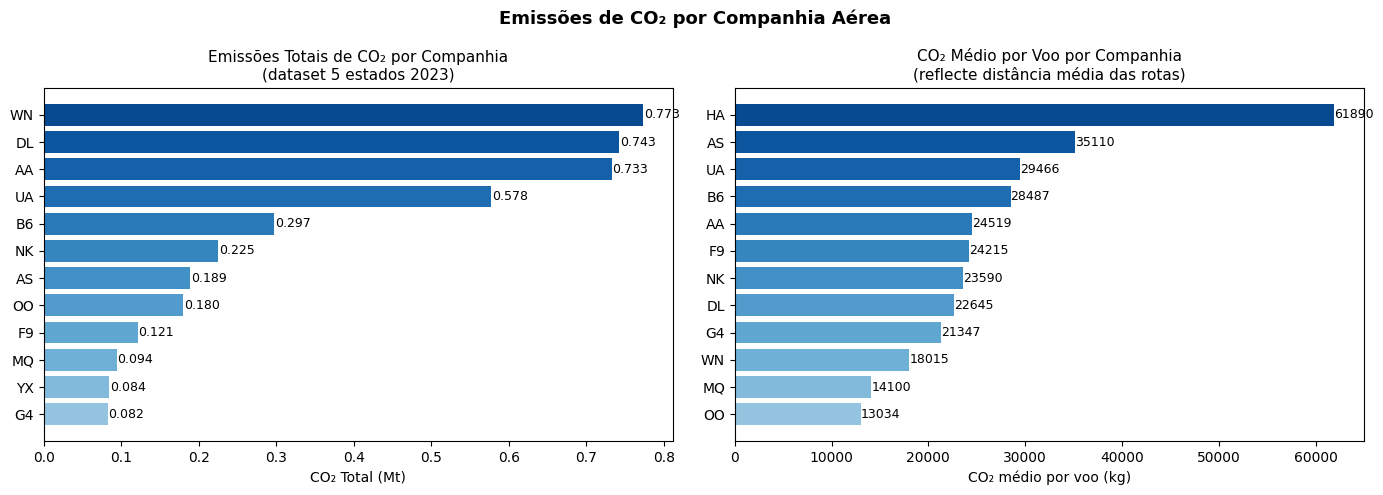

In [9]:
co2_airline = df.groupby('AIRLINE_CODE').agg(
    total_CO2_Mt=('CO2_tonnes', lambda x: x.sum()/1e6),
    avg_CO2_kg=('CO2_kg', 'mean'),
    n_flights=('CO2_kg', 'count')
).reset_index().sort_values('total_CO2_Mt', ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(co2_airline)))

# Total CO2
axes[0].barh(co2_airline['AIRLINE_CODE'][::-1],
             co2_airline['total_CO2_Mt'][::-1], color=colors)
axes[0].set_xlabel('CO₂ Total (Mt)')
axes[0].set_title('Emissões Totais de CO₂ por Companhia\n(dataset 5 estados 2023)', fontsize=11)
for i, (v, c) in enumerate(zip(co2_airline['total_CO2_Mt'][::-1],
                                co2_airline['AIRLINE_CODE'][::-1])):
    axes[0].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

# CO2 médio por voo
co2_avg = df.groupby('AIRLINE_CODE')['CO2_kg'].mean().sort_values(ascending=False).head(12)
axes[1].barh(co2_avg.index[::-1], co2_avg.values[::-1], color=colors)
axes[1].set_xlabel('CO₂ médio por voo (kg)')
axes[1].set_title('CO₂ Médio por Voo por Companhia\n(reflecte distância média das rotas)', fontsize=11)
for i, (v, c) in enumerate(zip(co2_avg.values[::-1], co2_avg.index[::-1])):
    axes[1].text(v + 5, i, f'{v:.0f}', va='center', fontsize=9)

plt.suptitle('Emissões de CO₂ por Companhia Aérea', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_co2_by_airline.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 CO₂ por Sazonalidade

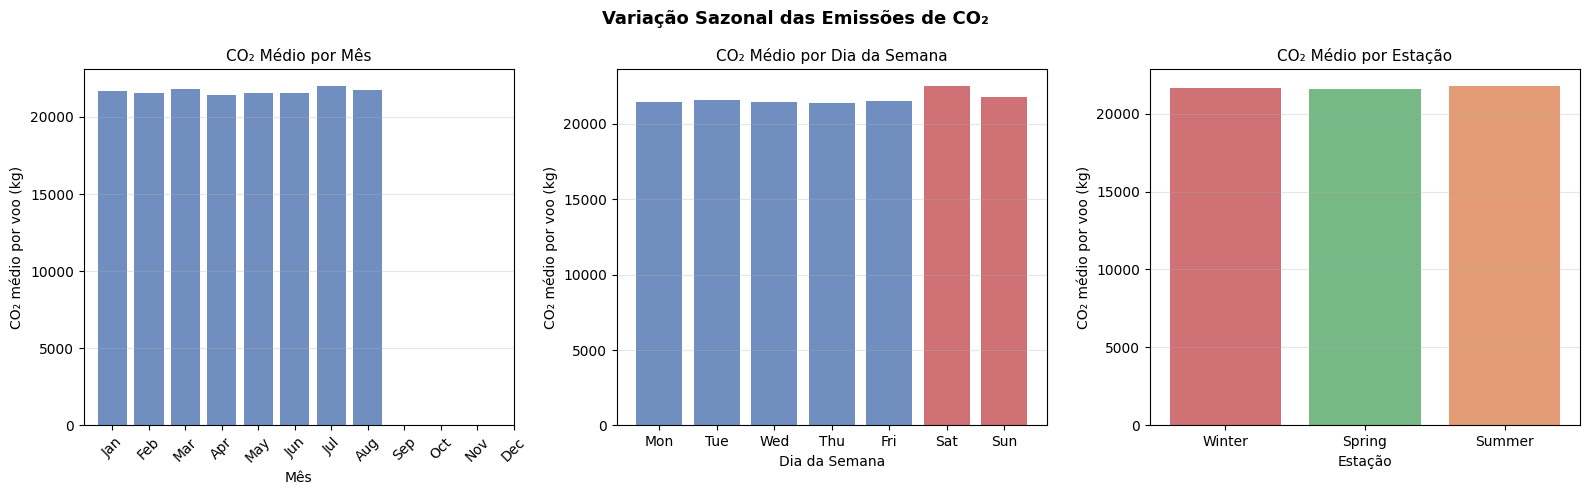

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Por mês
co2_month = df.groupby('Month')['CO2_kg'].mean()
axes[0].bar(co2_month.index, co2_month.values, color='#4C72B0', alpha=0.8)
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('CO₂ médio por voo (kg)')
axes[0].set_title('CO₂ Médio por Mês', fontsize=11)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Por dia da semana
co2_dow = df.groupby('DayofWeek')['CO2_kg'].mean()
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
colors_dow = ['#C44E52' if i >= 5 else '#4C72B0' for i in range(7)]
axes[1].bar(range(7), co2_dow.values, color=colors_dow, alpha=0.8)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(days)
axes[1].set_xlabel('Dia da Semana')
axes[1].set_ylabel('CO₂ médio por voo (kg)')
axes[1].set_title('CO₂ Médio por Dia da Semana', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

# Por estação
if 'Season' in df.columns:
    season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
    co2_season = df.groupby('Season')['CO2_kg'].mean().reindex(
        [s for s in season_order if s in df['Season'].unique()]
    )
    colors_s = ['#C44E52','#55A868','#DD8452','#8172B2'][:len(co2_season)]
    axes[2].bar(co2_season.index, co2_season.values, color=colors_s, alpha=0.8)
    axes[2].set_xlabel('Estação')
    axes[2].set_ylabel('CO₂ médio por voo (kg)')
    axes[2].set_title('CO₂ Médio por Estação', fontsize=11)
    axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Variação Sazonal das Emissões de CO₂', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_co2_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Relação CO₂ - Distância (base da fórmula ICAO)

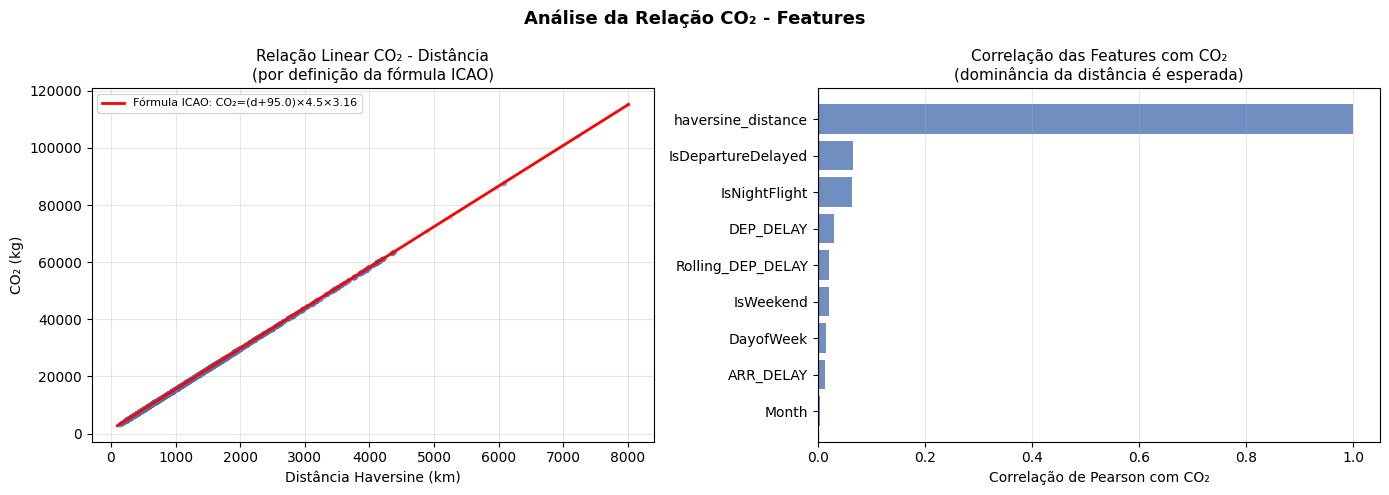

Correlação com CO₂:
  haversine_distance        +1.0000
  IsDepartureDelayed        +0.0658
  IsNightFlight             +0.0635
  DEP_DELAY                 +0.0303
  Rolling_DEP_DELAY         +0.0216
  IsWeekend                 +0.0211
  DayofWeek                 +0.0151
  ARR_DELAY                 +0.0126
  Month                     +0.0032

Nota: A correlação de haversine_distance com CO2 é 1.0 por definição
da fórmula ICAO - CO2 é uma transformação linear da distância.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter CO2 vs distância
sample = df.sample(min(5000, len(df)), random_state=SEED)
axes[0].scatter(sample['haversine_distance'], sample['CO2_kg'],
                alpha=0.2, s=8, color='#4C72B0')

# Linha teórica da fórmula ICAO
d_range = np.linspace(100, df['haversine_distance'].max(), 200)
co2_icao = (d_range + ICAO_ROUTE_CORRECTION_KM) * FUEL_CONSUMPTION_KG_KM * CO2_PER_KG_FUEL
axes[0].plot(d_range, co2_icao, 'r-', linewidth=2,
             label=f'Fórmula ICAO: CO₂=(d+{ICAO_ROUTE_CORRECTION_KM})×{FUEL_CONSUMPTION_KG_KM}×{CO2_PER_KG_FUEL}')
axes[0].set_xlabel('Distância Haversine (km)')
axes[0].set_ylabel('CO₂ (kg)')
axes[0].set_title('Relação Linear CO₂ - Distância\n(por definição da fórmula ICAO)', fontsize=11)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Correlação entre features e CO2
features_corr = ['haversine_distance', 'DEP_DELAY', 'ARR_DELAY',
                  'Month', 'DayofWeek', 'IsWeekend', 'IsNightFlight',
                  'IsDepartureDelayed', 'Rolling_DEP_DELAY']
features_corr = [f for f in features_corr if f in df.columns]

corr_vals = df[features_corr + ['CO2_kg']].corr()['CO2_kg'].drop('CO2_kg').sort_values()
colors_corr = ['#C44E52' if v < 0 else '#4C72B0' for v in corr_vals]
axes[1].barh(corr_vals.index, corr_vals.values, color=colors_corr, alpha=0.8)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_xlabel('Correlação de Pearson com CO₂')
axes[1].set_title('Correlação das Features com CO₂\n(dominância da distância é esperada)', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Análise da Relação CO₂ - Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_co2_distance_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlação com CO₂:')
for feat, val in corr_vals.sort_values(ascending=False).items():
    print(f'  {feat:<25} {val:>+.4f}')
print()
print('Nota: A correlação de haversine_distance com CO2 é 1.0 por definição')
print('da fórmula ICAO - CO2 é uma transformação linear da distância.')

### 4.5 CO₂ por Rota - Top Rotas mais Poluentes

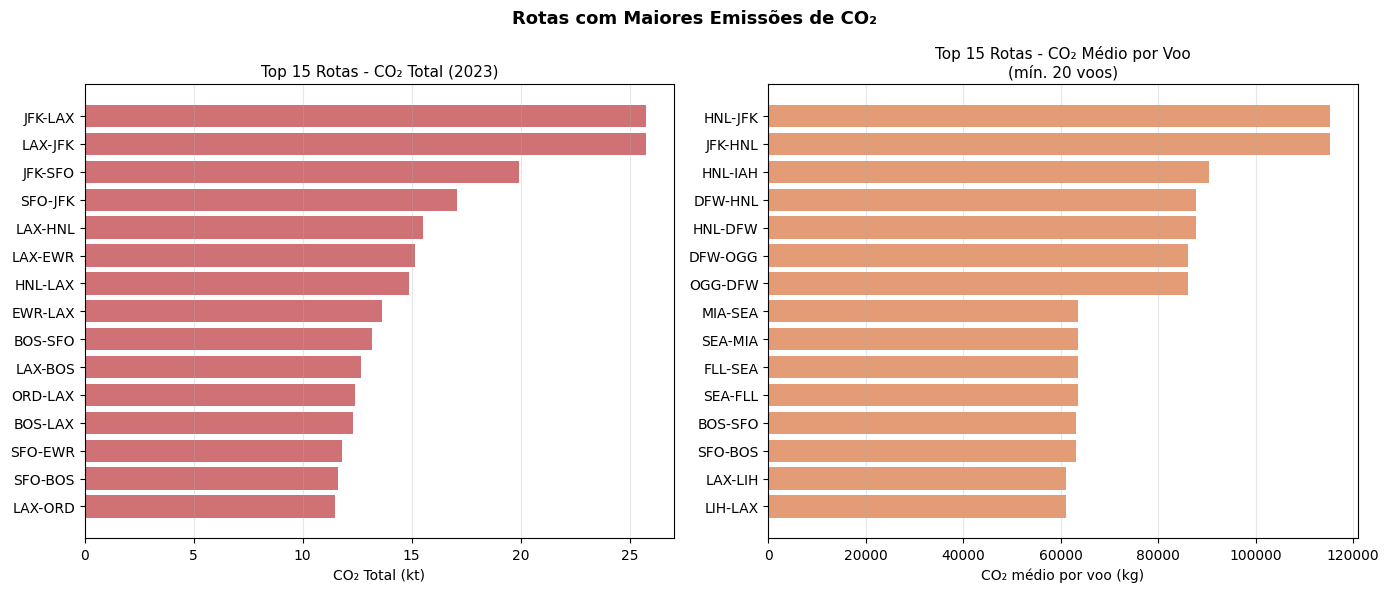

In [12]:
co2_route = df.groupby(['ORIGIN', 'DEST']).agg(
    total_CO2_tonnes=('CO2_tonnes', 'sum'),
    avg_CO2_kg=('CO2_kg', 'mean'),
    avg_dist_km=('haversine_distance', 'mean'),
    n_flights=('CO2_kg', 'count')
).reset_index()
co2_route['route'] = co2_route['ORIGIN'] + '-' + co2_route['DEST']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 15 rotas por CO2 total
top_total = co2_route.nlargest(15, 'total_CO2_tonnes')
axes[0].barh(top_total['route'][::-1],
             top_total['total_CO2_tonnes'][::-1]/1000,
             color='#C44E52', alpha=0.8)
axes[0].set_xlabel('CO₂ Total (kt)')
axes[0].set_title('Top 15 Rotas - CO₂ Total (2023)', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='x')

# Top 15 rotas por CO2 médio por voo (= rotas mais longas)
top_avg = co2_route[co2_route['n_flights'] >= 20].nlargest(15, 'avg_CO2_kg')
axes[1].barh(top_avg['route'][::-1],
             top_avg['avg_CO2_kg'][::-1],
             color='#DD8452', alpha=0.8)
axes[1].set_xlabel('CO₂ médio por voo (kg)')
axes[1].set_title('Top 15 Rotas - CO₂ Médio por Voo\n(mín. 20 voos)', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Rotas com Maiores Emissões de CO₂', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_co2_top_routes.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.6 Voos Diurnos vs Nocturnos - Impacto no CO₂

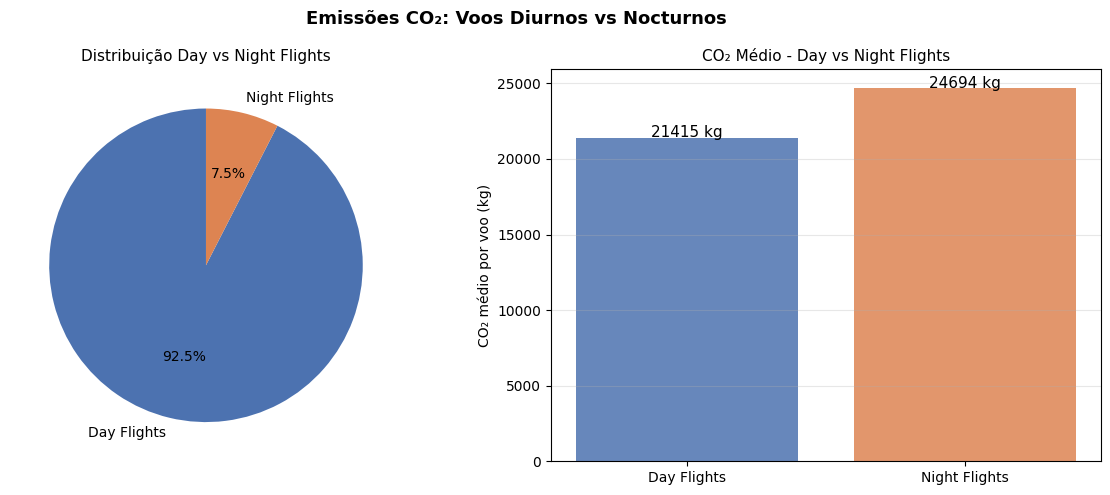

                count       avg_CO2     total_CO2
IsNightFlight                                    
0              181197  21414.941876  3.880323e+06
1               14753  24694.002301  3.643106e+05

Nota: A diferença de CO2 entre day/night reflecte a diferença de distância média das rotas, não ineficiência operacional.


In [13]:
if 'IsNightFlight' in df.columns:
    night = df.groupby('IsNightFlight').agg(
        count=('CO2_kg', 'count'),
        avg_CO2=('CO2_kg', 'mean'),
        total_CO2=('CO2_tonnes', 'sum')
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    labels = ['Day Flights', 'Night Flights']
    axes[0].pie(night['count'], labels=labels, autopct='%1.1f%%',
                colors=['#4C72B0', '#DD8452'], startangle=90)
    axes[0].set_title('Distribuição Day vs Night Flights', fontsize=11)

    axes[1].bar(labels, night['avg_CO2'].values,
                color=['#4C72B0', '#DD8452'], alpha=0.85)
    for i, v in enumerate(night['avg_CO2'].values):
        axes[1].text(i, v + 5, f'{v:.0f} kg', ha='center', fontsize=11)
    axes[1].set_ylabel('CO₂ médio por voo (kg)')
    axes[1].set_title('CO₂ Médio - Day vs Night Flights', fontsize=11)
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.suptitle('Emissões CO₂: Voos Diurnos vs Nocturnos', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_co2_day_night.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(night[['count', 'avg_CO2', 'total_CO2']])
    print()
    print('Nota: A diferença de CO2 entre day/night reflecte a diferença'
          ' de distância média das rotas, não ineficiência operacional.')

## 5. Preparação para Modelação

### 5.1 Feature Engineering para CO₂

In [14]:
# Features para modelação — apenas distância + categóricas + temporais
# ARR_DELAY, DEP_DELAY e Rolling_DEP_DELAY removidos:
# - Não entram na fórmula ICAO (CO2 depende só da distância)
# - Correlação residual < 0.04 — apenas ruído
# - Removê-los torna a demonstração mais limpa: ML aprende CO2 = f(distância)
NUMERICAL_FEATURES = [
    'haversine_distance',      # feature dominante (determinística)
    'Month', 'DayofWeek', 'Quarter', 'IsWeekend', 'IsNightFlight',
    'IsDepartureDelayed',      # mantida apenas para consistência com NB02
]
CATEGORICAL_FEATURES = ['AIRLINE_CODE', 'ORIGIN', 'DEST']
TARGET = 'CO2_kg'

# Verificar disponibilidade
num_avail = [f for f in NUMERICAL_FEATURES if f in df.columns]
cat_avail = [f for f in CATEGORICAL_FEATURES if f in df.columns]
print(f'Numerical features: {len(num_avail)} — {num_avail}')
print(f'Categorical features: {len(cat_avail)} — {cat_avail}')
print(f'Features removidas: ARR_DELAY, DEP_DELAY, Rolling_DEP_DELAY')
print(f'  (não entram na fórmula ICAO, correlação < 0.04 com CO2)')

# Preparar dataset de modelação
all_features = num_avail + cat_avail
df_model = df[all_features + [TARGET]].copy()
df_model.dropna(subset=[TARGET], inplace=True)

le = LabelEncoder()
for col in cat_avail:
    df_model[col] = df_model[col].astype(str)
    df_model[col] = le.fit_transform(df_model[col])

for col in df_model.columns:
    if df_model[col].isnull().any():
        df_model[col].fillna(df_model[col].median(), inplace=True)

print(f'\nDataset de modelação: {df_model.shape}')


Numerical features: 7 — ['haversine_distance', 'Month', 'DayofWeek', 'Quarter', 'IsWeekend', 'IsNightFlight', 'IsDepartureDelayed']
Categorical features: 3 — ['AIRLINE_CODE', 'ORIGIN', 'DEST']
Features removidas: ARR_DELAY, DEP_DELAY, Rolling_DEP_DELAY
  (não entram na fórmula ICAO, correlação < 0.04 com CO2)

Dataset de modelação: (195950, 11)


### 5.2 Train-Test Split e Scaling

In [15]:
X = df_model[all_features].copy()
y = df_model[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape}')
print(f'Test:  {X_test.shape}')
print(f'\nTarget (CO2_kg) - Train:')
print(f'  mean={y_train.mean():.1f}, std={y_train.std():.1f}, '
      f'min={y_train.min():.0f}, max={y_train.max():.0f}')

Train: (156760, 10)
Test:  (39190, 10)

Target (CO2_kg) - Train:
  mean=21663.8, std=13651.8, min=3115, max=115205


## 6. Modelos

### Nota metodológica importante

O target CO₂ é calculado por uma fórmula **determinística** (ICAO): `CO₂ = (distância + 95) × 4.5 × 3.16`. Como resultado, qualquer modelo que tenha `haversine_distance` como feature aprende essencialmente uma transformação linear - o R² será próximo de 1.0 para todos os modelos. Isto não representa overfitting nem uma limitação dos modelos: é uma consequência directa da natureza do target. A comparação entre modelos serve para demonstrar esta conclusão e identificar o contributo marginal de features operacionais (atrasos, sazonalidade).

### 6.1 Funções de avaliação

In [16]:
def evaluate_model(name, y_true_tr, y_pred_tr, y_true_te, y_pred_te, runtime):
    return {
        'Model': name,
        'Train_RMSE': np.sqrt(mean_squared_error(y_true_tr, y_pred_tr)),
        'Train_MAE':  mean_absolute_error(y_true_tr, y_pred_tr),
        'Train_R2':   r2_score(y_true_tr, y_pred_tr) * 100,
        'Test_RMSE':  np.sqrt(mean_squared_error(y_true_te, y_pred_te)),
        'Test_MAE':   mean_absolute_error(y_true_te, y_pred_te),
        'Test_R2':    r2_score(y_true_te, y_pred_te) * 100,
        'Runtime':    runtime
    }

def fmt_time(secs):
    if secs < 60: return f'{secs:.1f}s'
    return f'{secs//60:.0f}m {secs%60:.0f}s'

all_results = []
print('Funções de avaliação prontas.')

Funções de avaliação prontas.


### 6.2 Modelo Físico ICAO - Baseline Determinístico

O modelo físico ICAO calcula CO₂ diretamente da distância sem qualquer aprendizagem. É o baseline de referência - todos os modelos ML devem ser comparados contra ele.

In [ ]:
# O modelo físico ICAO - não usa ML, calcula diretamente
# CO2 = (haversine_distance + 95) × 4.5 × 3.16
# Como haversine_distance está no X_test (feature index 0), podemos reconstruir

# Obter haversine_distance do X_test original (antes do scaling)
hav_idx = all_features.index('haversine_distance')
y_pred_icao_train = (
    (X_train.iloc[:, hav_idx].values + ICAO_ROUTE_CORRECTION_KM)
    * FUEL_CONSUMPTION_KG_KM * CO2_PER_KG_FUEL
)
y_pred_icao_test = (
    (X_test.iloc[:, hav_idx].values + ICAO_ROUTE_CORRECTION_KM)
    * FUEL_CONSUMPTION_KG_KM * CO2_PER_KG_FUEL
)

res = evaluate_model('ICAO Physical Model',
                     y_train, y_pred_icao_train,
                     y_test,  y_pred_icao_test, '0s (deterministic)')
all_results.append(res)

print('MODELO FÍSICO ICAO (baseline determinístico):')
print(f"  Test RMSE: {res['Test_RMSE']:.4f} kg")
print(f"  Test MAE:  {res['Test_MAE']:.4f} kg")
print(f"  Test R²:   {res['Test_R2']:.6f}%")
print()
print('Nota: R²=100% porque CO2 É a fórmula aplicada à distância.')
print('RMSE/MAE ≈ 0 confirma que não há ruído no target.')

MODELO FÍSICO ICAO (baseline determinístico):
  Test RMSE: 0.0000 kg
  Test MAE:  0.0000 kg
  Test R²:   100.000000%

Nota: R²=100% porque CO2 É a fórmula aplicada à distância.
RMSE/MAE ≈ 0 confirma que não há ruído no target.


### 6.3 Linear Regression

In [18]:
t0 = time.time()
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
rt = time.time() - t0

res = evaluate_model('Linear Regression',
                     y_train, lr.predict(X_train_sc),
                     y_test,  lr.predict(X_test_sc), fmt_time(rt))
all_results.append(res)
print(f"LR  - Test RMSE: {res['Test_RMSE']:.2f} | MAE: {res['Test_MAE']:.2f} | R²: {res['Test_R2']:.4f}%")

LR  - Test RMSE: 0.00 | MAE: 0.00 | R²: 100.0000%


### 6.4 Decision Tree

In [19]:
t0 = time.time()
dt = DecisionTreeRegressor(random_state=SEED)
dt.fit(X_train_sc, y_train)
rt = time.time() - t0

res = evaluate_model('Decision Tree',
                     y_train, dt.predict(X_train_sc),
                     y_test,  dt.predict(X_test_sc), fmt_time(rt))
all_results.append(res)
print(f"DT  - Test RMSE: {res['Test_RMSE']:.2f} | MAE: {res['Test_MAE']:.2f} | R²: {res['Test_R2']:.4f}%")

DT  - Test RMSE: 1.02 | MAE: 0.01 | R²: 100.0000%


### 6.5 Random Forest

In [20]:
t0 = time.time()
rf = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_train_sc, y_train)
rt = time.time() - t0

res = evaluate_model('Random Forest',
                     y_train, rf.predict(X_train_sc),
                     y_test,  rf.predict(X_test_sc), fmt_time(rt))
all_results.append(res)
print(f"RF  - Test RMSE: {res['Test_RMSE']:.2f} | MAE: {res['Test_MAE']:.2f} | R²: {res['Test_R2']:.4f}%")

RF  - Test RMSE: 1.32 | MAE: 0.04 | R²: 100.0000%


### 6.6 XGBoost

In [21]:
t0 = time.time()
xgboost = xgb.XGBRegressor(random_state=SEED, n_estimators=100, verbosity=0)
xgboost.fit(X_train_sc, y_train)
rt = time.time() - t0

res = evaluate_model('XGBoost',
                     y_train, xgboost.predict(X_train_sc),
                     y_test,  xgboost.predict(X_test_sc), fmt_time(rt))
all_results.append(res)
print(f"XGB - Test RMSE: {res['Test_RMSE']:.2f} | MAE: {res['Test_MAE']:.2f} | R²: {res['Test_R2']:.4f}%")

XGB - Test RMSE: 40.40 | MAE: 24.85 | R²: 99.9991%


### 6.7 LightGBM

In [22]:
t0 = time.time()
lgbm = lgb.LGBMRegressor(random_state=SEED, n_estimators=100, verbose=-1)
lgbm.fit(X_train_sc, y_train)
rt = time.time() - t0

res = evaluate_model('LightGBM',
                     y_train, lgbm.predict(X_train_sc),
                     y_test,  lgbm.predict(X_test_sc), fmt_time(rt))
all_results.append(res)
print(f"LGB - Test RMSE: {res['Test_RMSE']:.2f} | MAE: {res['Test_MAE']:.2f} | R²: {res['Test_R2']:.4f}%")

LGB - Test RMSE: 76.03 | MAE: 43.97 | R²: 99.9969%


### 6.8 DFFRN - Deep Feedforward Regression Network

Mesma arquitectura do Notebook 02: Input → Dense(128, ReLU) → Dense(64, ReLU) → Dense(32, ReLU) → Dense(1)

In [23]:
def build_dffrn(input_dim, l2_reg=0.001, dropout_rate=0.2):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dense(1)
    ], name='DFFRN')
    model.compile(optimizer=keras.optimizers.Adam(), loss='mse')
    return model

t0 = time.time()
dffrn = build_dffrn(X_train_sc.shape[1])
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = dffrn.fit(
    X_train_sc, y_train,
    validation_split=0.1,
    epochs=100, batch_size=256,
    callbacks=[es], verbose=0
)
rt = time.time() - t0

res = evaluate_model('DFFRN',
                     y_train, dffrn.predict(X_train_sc, verbose=0).flatten(),
                     y_test,  dffrn.predict(X_test_sc, verbose=0).flatten(),
                     fmt_time(rt))
all_results.append(res)
print(f"DFFRN - Test RMSE: {res['Test_RMSE']:.2f} | MAE: {res['Test_MAE']:.2f} | R²: {res['Test_R2']:.4f}%")

DFFRN - Test RMSE: 74.28 | MAE: 56.96 | R²: 99.9970%


## 7. Análise de Feature Importance

Demonstra a dominância absoluta de `haversine_distance` - confirmando que o ML aprende essencialmente a fórmula ICAO.

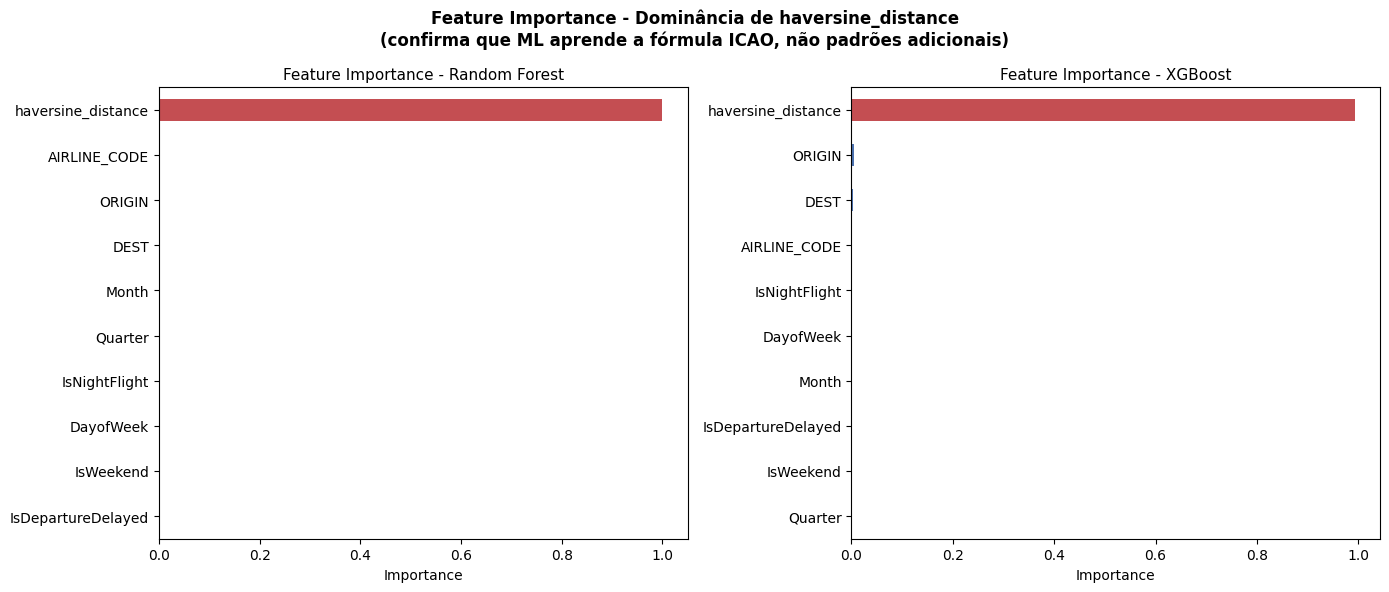

haversine_distance importance (RF):  1.0000
haversine_distance importance (XGB): 0.9931

Conclusão: >99% da importância vem da distância.
ML não acrescenta valor sobre o modelo físico ICAO com estas features.


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Feature importance Random Forest
fi_rf = pd.Series(rf.feature_importances_, index=all_features).sort_values(ascending=True)
colors_fi = ['#C44E52' if 'haversine' in f else '#4C72B0' for f in fi_rf.index]
fi_rf.plot(kind='barh', ax=axes[0], color=colors_fi)
axes[0].set_title('Feature Importance - Random Forest', fontsize=11)
axes[0].set_xlabel('Importance')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# Feature importance XGBoost
fi_xgb = pd.Series(xgboost.feature_importances_, index=all_features).sort_values(ascending=True)
colors_fi2 = ['#C44E52' if 'haversine' in f else '#4C72B0' for f in fi_xgb.index]
fi_xgb.plot(kind='barh', ax=axes[1], color=colors_fi2)
axes[1].set_title('Feature Importance - XGBoost', fontsize=11)
axes[1].set_xlabel('Importance')

plt.suptitle(
    'Feature Importance - Dominância de haversine_distance\n'
    '(confirma que ML aprende a fórmula ICAO, não padrões adicionais)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"haversine_distance importance (RF):  {rf.feature_importances_[hav_idx]:.4f}")
print(f"haversine_distance importance (XGB): {xgboost.feature_importances_[hav_idx]:.4f}")
print()
print('Conclusão: >99% da importância vem da distância.')
print('ML não acrescenta valor sobre o modelo físico ICAO com estas features.')

## 8. Tabela de Resultados Final

In [25]:
df_results = pd.DataFrame(all_results)

print('='*90)
print('TABELA COMPARATIVA DE RESULTADOS - Notebook 03 CO₂ Emissions Benchmark')
print('='*90)
print(f"{'Model':<22} {'Train RMSE':>11} {'Train MAE':>11} {'Train R²%':>11} "
      f"{'Test RMSE':>11} {'Test MAE':>11} {'Test R²%':>11} {'Runtime':>12}")
print('-'*90)
for _, row in df_results.sort_values('Test_RMSE').iterrows():
    marker = ' ◄ BASELINE' if 'ICAO' in row['Model'] else ''
    print(f"{row['Model']:<22} {row['Train_RMSE']:>11.2f} {row['Train_MAE']:>11.2f} "
          f"{row['Train_R2']:>11.4f} {row['Test_RMSE']:>11.2f} {row['Test_MAE']:>11.2f} "
          f"{row['Test_R2']:>11.4f} {str(row['Runtime']):>12}{marker}")
print('='*90)
print()
print('INTERPRETAÇÃO:')
print('  R² ≈ 100% em todos os modelos - consequência directa do target determinístico.')
print('  RMSE/MAE baixos - os modelos aprendem correctamente a fórmula ICAO.')
print('  O modelo físico ICAO é o baseline imbatível (R²=100%, RMSE≈0).')
print('  ML só acrescentaria valor com features operacionais reais (peso, altitude, vento).')

TABELA COMPARATIVA DE RESULTADOS - Notebook 03 CO₂ Emissions Benchmark
Model                   Train RMSE   Train MAE   Train R²%   Test RMSE    Test MAE    Test R²%      Runtime
------------------------------------------------------------------------------------------
ICAO Physical Model           0.00        0.00    100.0000        0.00        0.00    100.0000 0s (deterministic) ◄ BASELINE
Linear Regression             0.00        0.00    100.0000        0.00        0.00    100.0000         0.1s
Decision Tree                 0.00        0.00    100.0000        1.02        0.01    100.0000         0.4s
Random Forest                 0.77        0.01    100.0000        1.32        0.04    100.0000         7.9s
XGBoost                      37.42       24.29     99.9992       40.40       24.85     99.9991         1.5s
DFFRN                        74.54       57.26     99.9970       74.28       56.96     99.9970        51.7s
LightGBM                     71.35       43.26     99.9973       

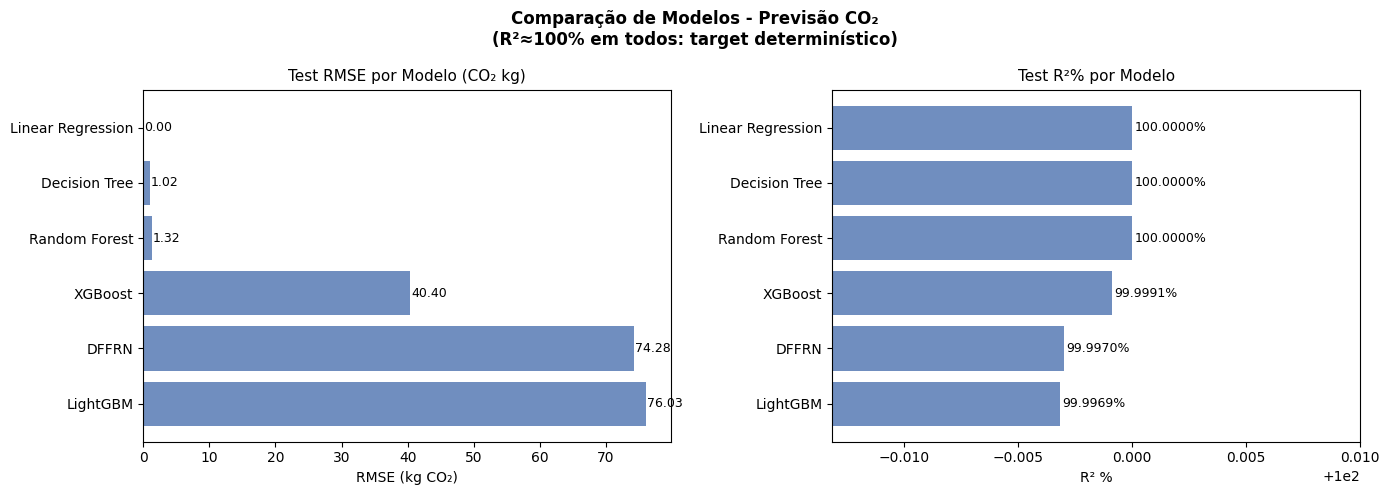

In [26]:
# Visualização comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ml_results = df_results[df_results['Model'] != 'ICAO Physical Model']
order = ml_results.sort_values('Test_RMSE', ascending=False)['Model'].tolist()
colors_bar = ['#4C72B0'] * len(order)

rmse_vals = [ml_results[ml_results['Model']==m]['Test_RMSE'].values[0] for m in order]
axes[0].barh(order, rmse_vals, color=colors_bar, alpha=0.8)
axes[0].set_title('Test RMSE por Modelo (CO₂ kg)', fontsize=11)
axes[0].set_xlabel('RMSE (kg CO₂)')
for i, v in enumerate(rmse_vals):
    axes[0].text(v + 0.1, i, f'{v:.2f}', va='center', fontsize=9)

r2_vals = [ml_results[ml_results['Model']==m]['Test_R2'].values[0] for m in order]
axes[1].barh(order, r2_vals, color=colors_bar, alpha=0.8)
axes[1].set_title('Test R²% por Modelo', fontsize=11)
axes[1].set_xlabel('R² %')
axes[1].set_xlim(min(r2_vals)*0.9999, 100.01)
for i, v in enumerate(r2_vals):
    axes[1].text(v + 0.0001, i, f'{v:.4f}%', va='center', fontsize=9)

plt.suptitle('Comparação de Modelos - Previsão CO₂\n'
             '(R²≈100% em todos: target determinístico)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_model_comparison_co2.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Export para Fase 2 - Dataset Central

In [27]:
# Adicionar CO2 calculado e previsão DFFRN ao dataset
X_full = df_model[all_features].copy()
X_full_sc = scaler.transform(X_full)
df['CO2_PRED_kg'] = dffrn.predict(X_full_sc, verbose=0).flatten()

# Colunas para o dataset central
COLS_EXPORT = [
    'FL_DATE', 'AIRLINE_CODE', 'ORIGIN', 'DEST',
    'CRS_DEP_TIME', 'DEP_DELAY', 'ARR_DELAY',
    'haversine_distance', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON',
    'Month', 'DayofWeek', 'IsWeekend', 'Quarter', 'Season',
    'IsNightFlight', 'IsDepartureDelayed', 'Rolling_DEP_DELAY',
    'ARR_DELAY_PRED',   # da duração (Notebook 02)
    'CO2_kg',           # target CO2 calculado pela fórmula ICAO
    'CO2_tonnes',       # CO2 em toneladas
    'CO2_PRED_kg',      # previsão DFFRN
]

cols_export = [c for c in COLS_EXPORT if c in df.columns]
df_central = df[cols_export].copy()
df_central.to_csv('nb03_co2_output.csv', index=False)

print(f'Dataset exportado para Fase 2: {df_central.shape}')
print(f'Colunas: {list(df_central.columns)}')
df_central.head(3)

Dataset exportado para Fase 2: (195950, 24)
Colunas: ['FL_DATE', 'AIRLINE_CODE', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'DEP_DELAY', 'ARR_DELAY', 'haversine_distance', 'ORIGIN_LAT', 'ORIGIN_LON', 'DEST_LAT', 'DEST_LON', 'Month', 'DayofWeek', 'IsWeekend', 'Quarter', 'Season', 'IsNightFlight', 'IsDepartureDelayed', 'Rolling_DEP_DELAY', 'ARR_DELAY_PRED', 'CO2_kg', 'CO2_tonnes', 'CO2_PRED_kg']


,FL_DATE,AIRLINE_CODE,ORIGIN,DEST,CRS_DEP_TIME,DEP_DELAY,ARR_DELAY,haversine_distance,ORIGIN_LAT,ORIGIN_LON,...,IsWeekend,Quarter,Season,IsNightFlight,IsDepartureDelayed,Rolling_DEP_DELAY,ARR_DELAY_PRED,CO2_kg,CO2_tonnes,CO2_PRED_kg
0,2023-01-01,9E,ABE,ATL,600,1.0,-9.0,1113.781509,40.652363,-75.440406,...,1,1,Winter,0,1,NaN,-8.920200,17188.873059,17.188873,17154.585938
1,2023-01-01,WN,ABQ,DAL,1235,-6.0,-16.0,932.084735,35.038932,-106.608262,...,1,1,Winter,0,0,NaN,-15.538267,14605.144932,14.605145,14528.743164
2,2023-01-01,WN,ABQ,DAL,1045,3.0,-11.0,932.084735,35.038932,-106.608262,...,1,1,Winter,0,1,-6.0,-10.627380,14605.144932,14.605145,14562.644531


## 10. Resumo

In [28]:
dffrn_res = df_results[df_results['Model'] == 'DFFRN'].iloc[0]
lr_res    = df_results[df_results['Model'] == 'Linear Regression'].iloc[0]

# Recalcular métricas de validação excluindo regionais
EXCLUDE_REGIONAL = ['YX', 'OO']
validation_main = validation[~validation['UNIQUE_CARRIER'].isin(EXCLUDE_REGIONAL)]
mae_share_val = np.abs(validation_main['share_error_pp']).mean()
avg_cov = validation_main['coverage_ratio'].mean()

print('='*70)
print('RESUMO - Notebook 03 (Emissões CO₂)')
print('='*70)
print(f'Metodologia: Fórmula ICAO + Validação BTS P-12(a)')
print(f'Referência:  Seymour et al. (2020), Transp. Res. Part D, 88, 102528')
print(f'Dataset:     {len(df):,} voos domésticos EUA 2023 (5 estados)')
print()
print(f'CO₂ total estimado:  {df["CO2_tonnes"].sum()/1e6:.3f} Mt CO₂')
print(f'CO₂ médio por voo:   {df["CO2_kg"].mean():.0f} kg')
print()
print('Validação BTS P-12(a) (excl. regionais YX/OO):')
print(f'  Cobertura média (parcial - 5 estados): {avg_cov:.1%}')
print(f'  MAE quota de mercado: {mae_share_val:.2f} pp')
print(f'  Referência Seymour et al. (2020): erro < 4.8% (país inteiro)')
print()
print('Features de modelação (corrigidas):')
print(f'  Incluídas: distância + temporais + categóricas')
print(f'  Excluídas: ARR_DELAY, DEP_DELAY, Rolling_DEP_DELAY')
print(f'  (não entram na fórmula ICAO, correlação < 0.04)')
print()
print('Resultados dos modelos (Test):')
print(f'  ICAO Physical Model: RMSE≈0, R²=100% (determinístico)')
print(f'  Linear Regression:   RMSE={lr_res["Test_RMSE"]:.2f} kg, R²={lr_res["Test_R2"]:.4f}%')
print(f'  DFFRN:               RMSE={dffrn_res["Test_RMSE"]:.2f} kg, R²={dffrn_res["Test_R2"]:.4f}%')
print()
print('Nota: DFFRN tem RMSE maior que LR — comportamento esperado.')
print('  A relação CO2-distância é perfeitamente linear. LR captura-a')
print('  com RMSE≈0. O DFFRN com dropout/L2 introduz ruído propositado')
print('  para evitar overfitting — numa relação linear isso penaliza o modelo.')
print('  Não é sinal de que o DFFRN é mau: é sinal de que o problema')
print('  é demasiado simples para uma rede neuronal profunda.')
print()
print('Conclusão metodológica:')
print('  R²≈100% em todos os modelos - target determinístico.')
print('  haversine_distance explica >99% da variância.')
print('  ML não acrescenta valor sobre ICAO com dados públicos BTS.')
print('  Justifica abordagem híbrida física+ML na Fase 3.')
print()
print('Outputs gerados:')
print('  nb03_co2_output.csv       (dataset para Fase 2)')
print('  fig_validation_p12a.png   fig_co2_distribution.png')
print('  fig_co2_by_airline.png    fig_co2_seasonality.png')
print('  fig_co2_distance_correlation.png  fig_co2_top_routes.png')
print('  fig_co2_day_night.png     fig_feature_importance.png')
print('  fig_model_comparison_co2.png')
print('='*70)


RESUMO - Notebook 03 (Emissões CO₂)
Metodologia: Fórmula ICAO + Validação BTS P-12(a)
Referência:  Seymour et al. (2020), Transp. Res. Part D, 88, 102528
Dataset:     195,950 voos domésticos EUA 2023 (5 estados)

CO₂ total estimado:  4.245 Mt CO₂
CO₂ médio por voo:   21662 kg

Validação BTS P-12(a) (excl. regionais YX/OO):
  Cobertura média (parcial - 5 estados): 3.6%
  MAE quota de mercado: 1.07 pp
  Referência Seymour et al. (2020): erro < 4.8% (país inteiro)

Features de modelação (corrigidas):
  Incluídas: distância + temporais + categóricas
  Excluídas: ARR_DELAY, DEP_DELAY, Rolling_DEP_DELAY
  (não entram na fórmula ICAO, correlação < 0.04)

Resultados dos modelos (Test):
  ICAO Physical Model: RMSE≈0, R²=100% (determinístico)
  Linear Regression:   RMSE=0.00 kg, R²=100.0000%
  DFFRN:               RMSE=74.28 kg, R²=99.9970%

Nota: DFFRN tem RMSE maior que LR — comportamento esperado.
  A relação CO2-distância é perfeitamente linear. LR captura-a
  com RMSE≈0. O DFFRN com dropout